In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import yfinance as yf
import warnings
from IPython.display import display

root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.simulation import MarketSimulator
from src.metrics import MarketMetrics, plot_susceptibility_curve
from scipy.stats import norm

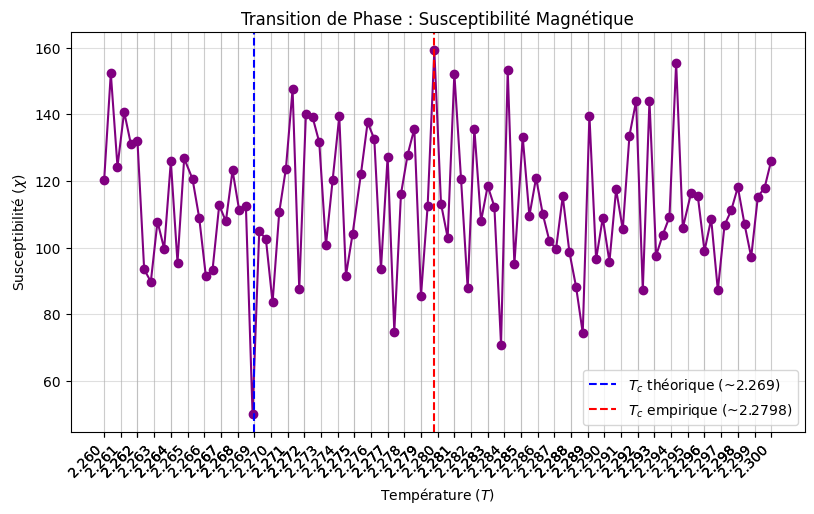

In [2]:
list_T = np.linspace(2.26, 2.3, 100)
dict_results = {}
counts = 5
N_agents = 1000

for T in list_T:
    susceptibilities_for_T = []
    
    for _ in range(counts):
        sim = MarketSimulator(
            N=N_agents,     
            T=T,        
            J=1.0,       
            h_0=0.0,          
            Delta_t=1000, 
            P_0=100,  
            lambd_0=100  
        )
        
        filename = sim.run()
        analyzer = MarketMetrics(filename)
        susceptibility = analyzer.calculate_susceptibility(N_agents, T)
        
        susceptibilities_for_T.append(susceptibility)
    
    # Calcul de la moyenne sur les 5 simulations indépendantes
    mean_susceptibility = np.mean(susceptibilities_for_T)
    
    # Stockage dans le dictionnaire pour le tracé de la courbe
    dict_results[f"{T:.4f}"] = mean_susceptibility

# Tracé final avec la susceptibilité moyennée (courbe beaucoup plus lisse)
T_c = plot_susceptibility_curve(dict_results)

In [3]:
# Initialisation du simulateur
T = T_c 
N = 2000

sim = MarketSimulator(
    N=N,          # Taille du réseau (50x50)
    T=T,        # Température (proche du point critique)
    J=1.0,         # Interaction
    h_0=0.0,         # Champ externe
    Delta_t=20000,  # Nombre de pas de temps
    P_0=100,       # Prix initial
    lambd_0=100      # Liquidité
)

# Lancement et export automatique en .parquet
filename = sim.run()
df = pd.read_parquet(filename)

<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/0q/z_dwszqd10scbmvs1r972gdh0000gn/T/ipykernel_3071/424077780.py:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax1.set_ylabel('ln Prix ($\ln P_t$)')


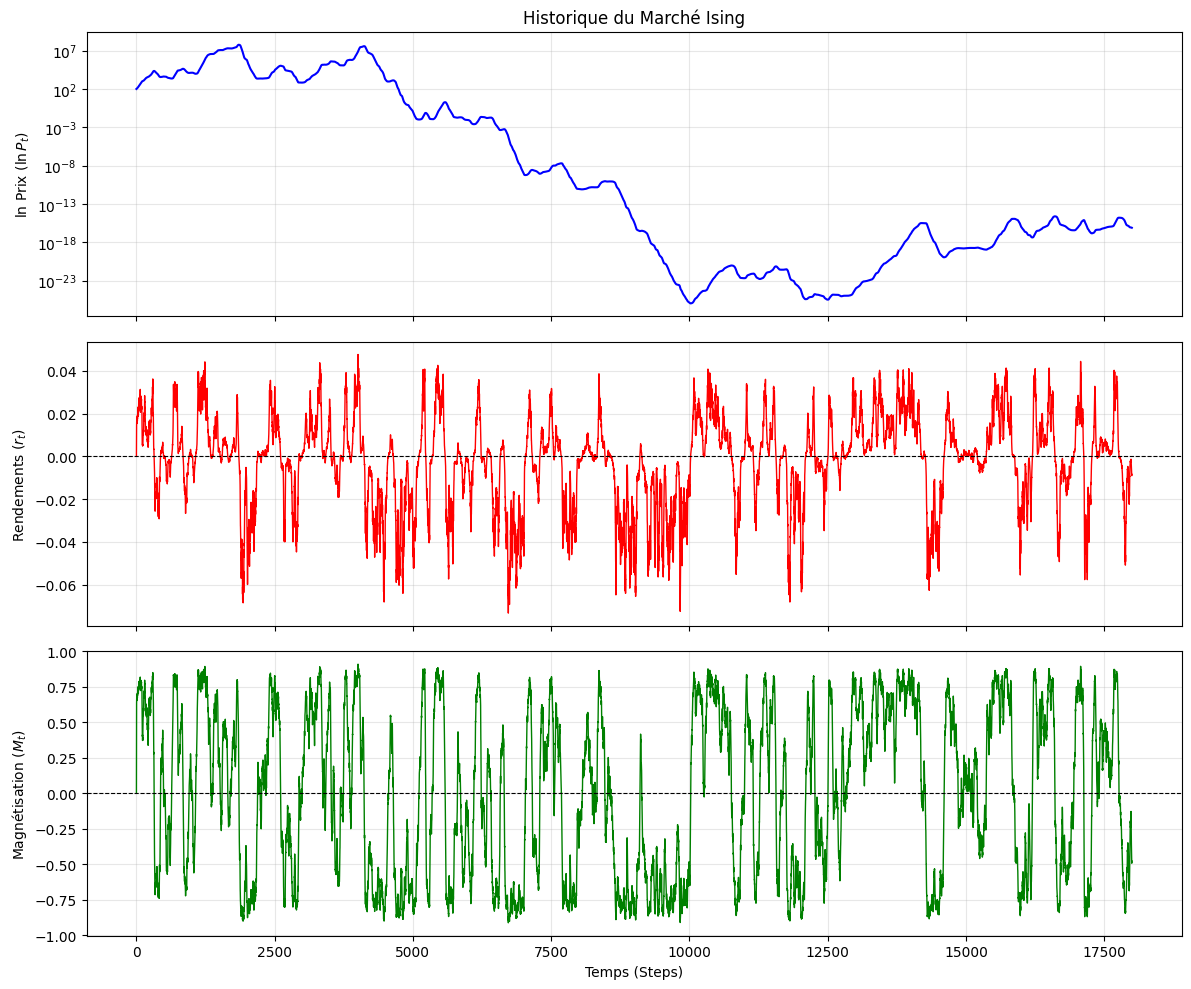

In [4]:
# Création de la figure avec 3 sous-graphiques (subplots)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Graphique du Prix
ax1.semilogy(df['time'], df['P_history'], color='blue', lw=1.5)
ax1.set_ylabel('ln Prix ($\ln P_t$)')
ax1.set_title('Historique du Marché Ising')
ax1.grid(alpha=0.3)

# 2. Graphique des Rendements
ax2.plot(df['time'], df['r_history'], color='red', lw=1)
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_ylabel('Rendements ($r_t$)')
ax2.grid(alpha=0.3)

# 3. Graphique de la Magnétisation
ax3.plot(df['time'], df['m_history'], color='green', lw=1)
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.set_ylabel('Magnétisation ($M_t$)')
ax3.set_xlabel('Temps (Steps)')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

--- Résultats de l'Analyse ---
Volatilité (Ecart-type) : 0.02081300824246486
Asymétrie (Skewness) : -0.5369768392405628
Excès de Kurtosis : 0.07266922074392168
Jarque-Bera p-value : 2.1366804073119002e-189
Est une Loi Normale ? : False
Susceptibility : 286.6624466112237


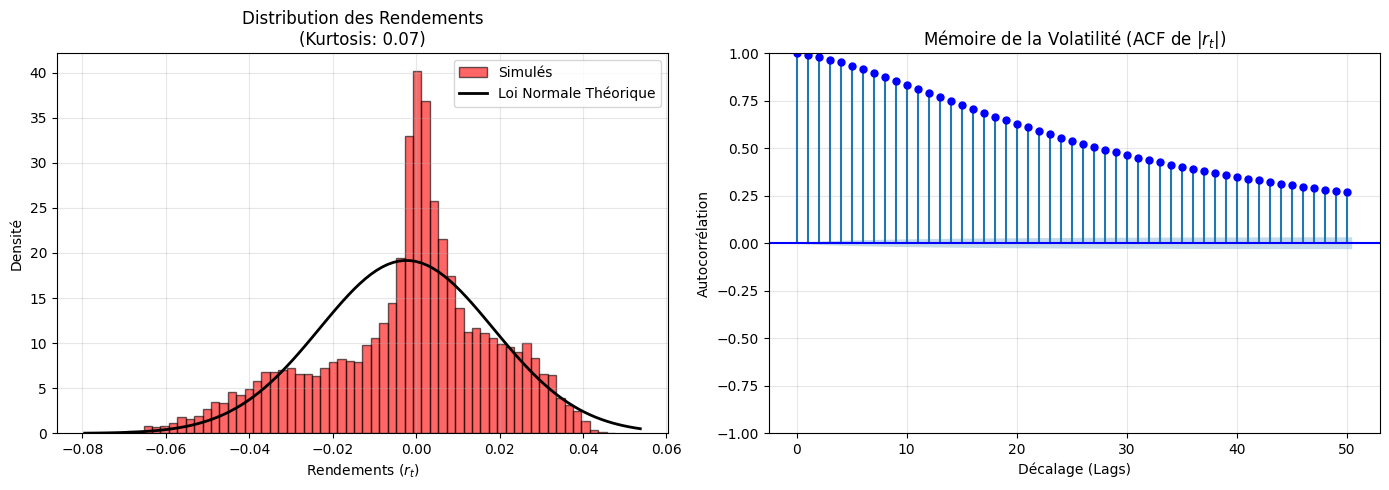

In [5]:
analyzer = MarketMetrics(filename)

financial_stats = analyzer.analyze_returns()

print("--- Résultats de l'Analyse ---")
for metric, valeur in financial_stats.items():
    print(f"{metric} : {valeur}")
    
susceptibility = analyzer.calculate_susceptibility(N, T)
print(f"Susceptibility : {susceptibility}")

# 3. Afficher les graphiques de validation (Histogramme + ACF)
analyzer.plot_stylized_facts()

🚀 Lancement du scan de phase (36 simulations)... Cela peut prendre quelques minutes.
✅ Température T=2.15 terminée.
✅ Température T=2.18 terminée.
✅ Température T=2.22 terminée.
✅ Température T=2.25 terminée.
✅ Température T=2.29 terminée.
✅ Température T=2.32 terminée.
✅ Température T=2.36 terminée.
✅ Température T=2.39 terminée.
✅ Température T=2.42 terminée.
✅ Température T=2.46 terminée.
✅ Température T=2.49 terminée.
✅ Température T=2.53 terminée.
✅ Température T=2.56 terminée.
✅ Température T=2.59 terminée.
✅ Température T=2.63 terminée.
✅ Température T=2.66 terminée.
✅ Température T=2.70 terminée.
✅ Température T=2.73 terminée.
✅ Température T=2.77 terminée.
✅ Température T=2.80 terminée.


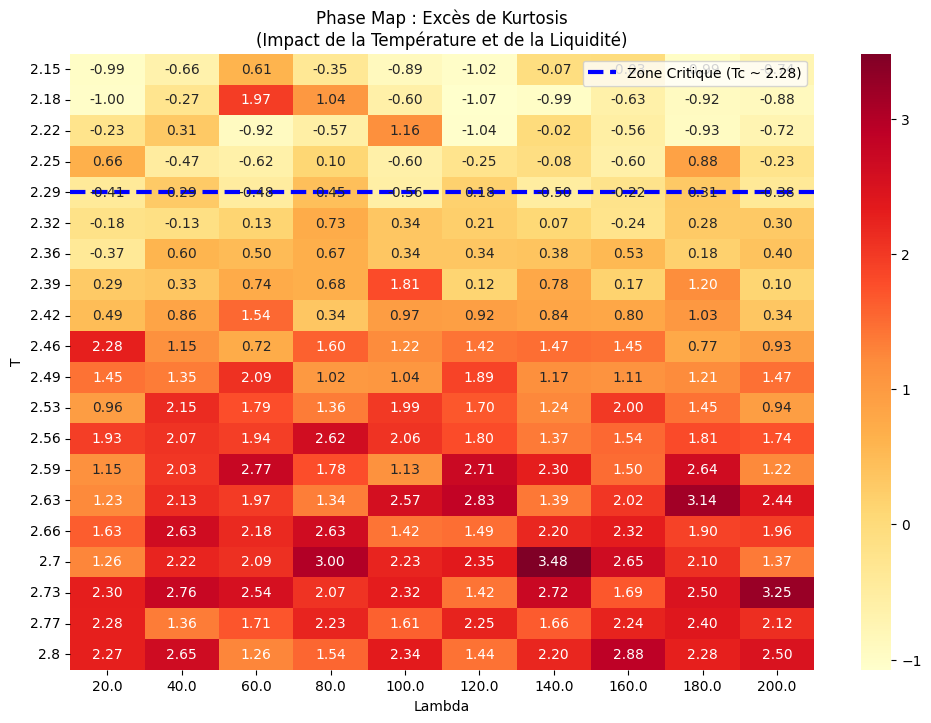

In [6]:
# 1. Paramétrage des plages de test
# On se focalise autour de ton Tc critique pour voir la transition
temp_range = np.linspace(2.15, 2.8, 20)   
# On teste de très liquide (200) à peu liquide (20)
lambda_range = np.linspace(20, 200, 10)  

kurt_max = 0

# Initialisation de la matrice pour stocker le Kurtosis
kurt_matrix = np.zeros((len(temp_range), len(lambda_range)))

print("🚀 Lancement du scan de phase (36 simulations)... Cela peut prendre quelques minutes.")

# 2. Boucle de simulation croisée
for i, T in enumerate(temp_range):
    for j, L in enumerate(lambda_range):
        # On utilise des paramètres un peu plus légers pour que le scan soit rapide
        sim = MarketSimulator(
            N=1000,     
            T=T,        
            J=1.0,       
            h_0=0.0,      
            Delta_t=8000, 
            P_0=100,  
            lambd_0=L  
        )
        
        # On lance la simulation
        filename = sim.run() 
        
        # On analyse directement le DataFrame en mémoire (plus rapide que lire/écrire des fichiers)
        df = pd.read_parquet(filename)
        analyzer = MarketMetrics(df)
        stats = analyzer.analyze_returns()
        
        # On stocke le Kurtosis
        current_kurt = stats["Excès de Kurtosis"]
        kurt_matrix[i, j] = current_kurt
        
        if current_kurt > kurt_max:
            kurt_max = current_kurt
            df_kurt_max = df.copy()
            filename_kurt_max = filename
    
    print(f"✅ Température T={T:.2f} terminée.")

# 3. Création de la Heatmap avec Seaborn
plt.figure(figsize=(12, 8))

# On prépare les données
df_heatmap = pd.DataFrame(
    kurt_matrix, 
    index=np.round(temp_range, 2), 
    columns=np.round(lambda_range, 0)
)

# On trace la heatmap
sns.heatmap(df_heatmap, annot=True, fmt=".2f", cmap="YlOrRd")

# --- CORRECTION DE LA LIGNE BLEUE ---
# On cherche l'indice de la température la plus proche de 2.27
tc_theorique = T_c
# On trouve quelle ligne (0, 1, 2...) correspond au T le plus proche
idx_proche = np.argmin(np.abs(temp_range - tc_theorique))

# On ajoute la ligne (0.5 permet de centrer la ligne sur la case)
plt.axhline(y=idx_proche + 0.5, color='blue', linestyle='--', linewidth=3, 
            label=f'Zone Critique (Tc ~ {T_c:.2f})')
plt.xlabel('Lambda')
plt.ylabel('T')
plt.title("Phase Map : Excès de Kurtosis\n(Impact de la Température et de la Liquidité)")
plt.legend()
plt.show()

<>:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/0q/z_dwszqd10scbmvs1r972gdh0000gn/T/ipykernel_3071/3406543647.py:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.xlabel("Rendements standardisés ($\sigma$)")
[*********************100%***********************]  1 of 1 completed


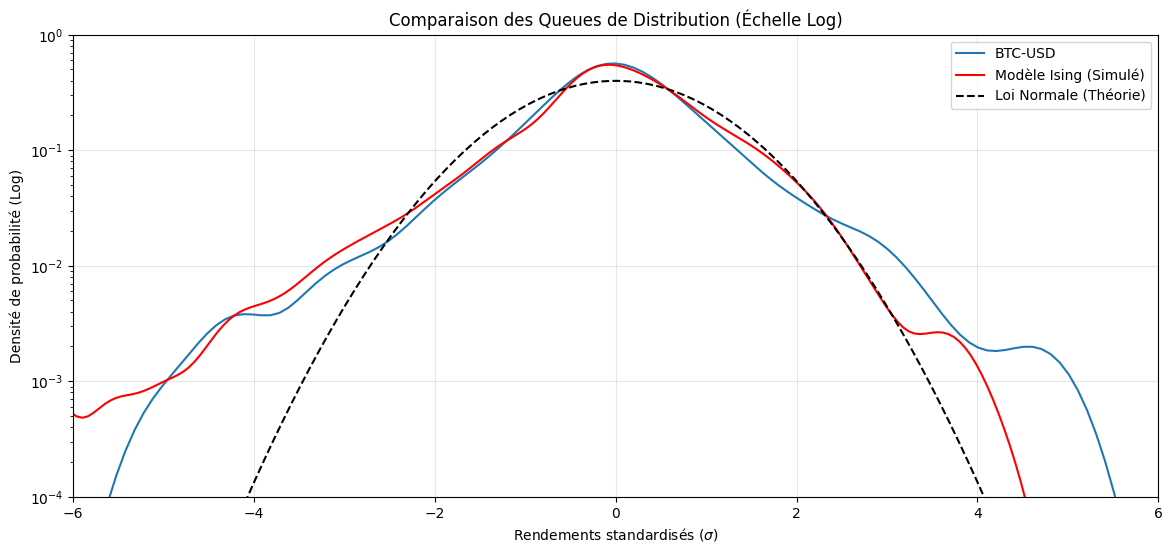

--- Résultats de l'Analyse ---
Volatilité (Ecart-type) : 0.004751844777275146
Asymétrie (Skewness) : -0.6791124310274017
Excès de Kurtosis : 3.4796103512996104
Jarque-Bera p-value : 0.0
Est une Loi Normale ? : False
Susceptibility : 83.91008394848822


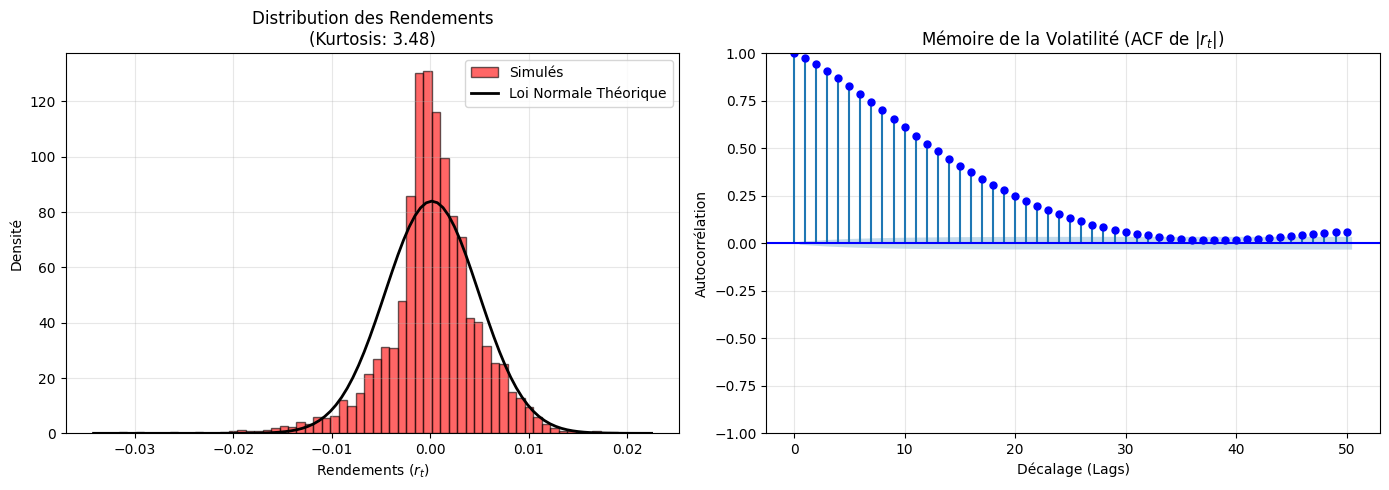

In [7]:
ticker = "BTC-USD"#"^GSPC" # S&P 500 (ou "BTC-USD" pour le Bitcoin)
data = yf.download(ticker, start="2019-01-01", end="2024-01-01")

# Calcul des rendements logarithmiques (log-returns)
real_returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()

def compare_to_reality(sim_returns, real_returns):
    plt.figure(figsize=(14, 6))
    
    # Standardisation (pour comparer des pommes avec des pommes)
    # On ramène les deux distributions à une moyenne de 0 et un écart-type de 1
    sim_std = (sim_returns - sim_returns.mean()) / sim_returns.std()
    real_std = (real_returns - real_returns.mean()) / real_returns.std()
    
    # Plot des distributions
    sns.kdeplot(real_std, label=f"{ticker}", color='blue', bw_adjust=1.5)
    sns.kdeplot(sim_std, label="Modèle Ising (Simulé)", color='red', bw_adjust=1.5)
    
    # Loi Normale pour référence
    x = np.linspace(-5, 5, 100)
    plt.plot(x, norm.pdf(x), 'k--', label="Loi Normale (Théorie)")
    
    plt.yscale('log') # PASSAGE EN LOG POUR VOIR LES QUEUES
    plt.ylim(1e-4, 1)
    plt.xlim(-6, 6)
    
    plt.title("Comparaison des Queues de Distribution (Échelle Log)")
    plt.xlabel("Rendements standardisés ($\sigma$)")
    plt.ylabel("Densité de probabilité (Log)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Utilise les rendements de ton meilleur run
compare_to_reality(df_kurt_max['r_history'], real_returns) # Remplace chi_vals par tes r_t simulés

analyzer = MarketMetrics(filename_kurt_max)

financial_stats = analyzer.analyze_returns()

print("--- Résultats de l'Analyse ---")
for metric, valeur in financial_stats.items():
    print(f"{metric} : {valeur}")
    
susceptibility = analyzer.calculate_susceptibility(N, T)
print(f"Susceptibility : {susceptibility}")

# 3. Afficher les graphiques de validation (Histogramme + ACF)
analyzer.plot_stylized_facts()


In [8]:
# Désactiver les warnings pandas pour garder la console propre
warnings.filterwarnings('ignore')

# ==========================================
# 1. PARAMÈTRES FIXES ET CIBLES
# ==========================================
N_agents = 1000
Delta_t = 8000
n_iterations = 100  # Nombre de combinaisons aléatoires à tester

# Cibles pour ressembler au Bitcoin
TARGET_KURTOSIS = 12.0
TARGET_SKEWNESS = -1.5 

# ==========================================
# 2. FONCTION DE SCORE (Fitness)
# ==========================================
def calculate_score(kurtosis, skewness):
    """
    Calcule la distance par rapport au profil du Bitcoin.
    Un score proche de 0 est parfait.
    On pénalise fortement un Kurtosis négatif et un Skewness positif.
    """
    if pd.isna(kurtosis) or pd.isna(skewness):
        return float('inf')
    
    # Distance au Kurtosis (poids de 1)
    error_kurt = abs(kurtosis - TARGET_KURTOSIS)
    
    # Distance au Skewness (poids de 3 car l'asymétrie est très importante ici)
    error_skew = 3 * abs(skewness - TARGET_SKEWNESS)
    
    return error_kurt + error_skew

# ==========================================
# 3. BOUCLE DE RECHERCHE ALÉATOIRE
# ==========================================
results_list = []

print(f"🚀 Lancement de l'optimisation sur {n_iterations} itérations...")
print(f"Fixe : T = {T_c} | Objectif : Kurtosis ~ {TARGET_KURTOSIS}, Skewness ~ {TARGET_SKEWNESS}\n")

for i in range(n_iterations):
    # Tirage aléatoire dans des plages stratégiques
    a_neg = np.random.uniform(3.0, 6.0)     # L'asymétrie baisse doit être forte
    a_pos = np.random.uniform(0.5, 2.5)     # L'asymétrie hausse plus faible
    p_val = np.random.choice([2, 3])        # Exposant quadratique ou cubique
    rho_val = np.random.uniform(0.85, 0.96) # Mémoire : on évite 0.99 qui sature le réseau
    sigma_val = np.random.uniform(0.005, 0.03) # Bruit : subtil pour ne pas écraser Ising
    
    try:
        # Instanciation du simulateur avec les paramètres tirés au sort
        sim = MarketSimulator(
            N=N_agents, 
            T=T_c, 
            J=1.0, 
            h_0=0.0,
            rho=rho_val,
            sigma_h=sigma_val,
            Delta_t=Delta_t, 
            P_0=100, 
            lambd_0=100,
            alpha_neg=a_neg,
            alpha_pos=a_pos,
            p=p_val
        )
        
        # Lancement et analyse
        filename = sim.run()
        analyzer = MarketMetrics(filename)
        stats = analyzer.analyze_returns() # Assure-toi que cette fonction renvoie bien un dict
        
        kurt = stats.get("Excès de Kurtosis", float('nan'))
        skew = stats.get("Asymétrie (Skewness)", float('nan'))
        
        # Calcul du score
        score = calculate_score(kurt, skew)
        
        # Stockage
        results_list.append({
            "Score": score,
            "Kurtosis": kurt,
            "Skewness": skew,
            "alpha_neg": a_neg,
            "alpha_pos": a_pos,
            "p": p_val,
            "rho": rho_val,
            "sigma_h": sigma_val,
            "file": filename
        })
        
    except Exception as e:
        print(f"Crash à l'itération {i} : {e}")

    # Suivi de la progression
    if (i + 1) % 10 == 0:
        print(f"⏳ {i + 1}/{n_iterations} simulations terminées...")

# ==========================================
# 4. ANALYSE DES RÉSULTATS
# ==========================================
# Conversion en DataFrame et tri par le meilleur score (le plus bas)
df_results = pd.DataFrame(results_list)
df_results = df_results.sort_values(by="Score", ascending=True).reset_index(drop=True)

print("\n✅ Optimisation terminée ! Voici le Top 5 des meilleures configurations :")
display(df_results.head(5))

# Sauvegarde des résultats du scan pour analyse ultérieure
df_results.to_csv("optimisation_params_bitcoin.csv", index=False)
best_filename = df_results.loc[0, 'file']

🚀 Lancement de l'optimisation sur 100 itérations...
Fixe : T = 2.2798 | Objectif : Kurtosis ~ 12.0, Skewness ~ -1.5

⏳ 10/100 simulations terminées...
⏳ 20/100 simulations terminées...
⏳ 30/100 simulations terminées...
⏳ 40/100 simulations terminées...
⏳ 50/100 simulations terminées...
⏳ 60/100 simulations terminées...
⏳ 70/100 simulations terminées...
⏳ 80/100 simulations terminées...
⏳ 90/100 simulations terminées...
⏳ 100/100 simulations terminées...

✅ Optimisation terminée ! Voici le Top 5 des meilleures configurations :


,Score,Kurtosis,Skewness,alpha_neg,alpha_pos,p,rho,sigma_h,file
0,3.018627,11.638753,-2.385794,4.436950,0.707433,3,0.906330,0.010906,data/N1000_T2.28_J1.0_h0.0_t8000_l100_an4.4369...
1,5.021163,12.253333,-3.089277,5.317245,0.661376,3,0.917634,0.020131,data/N1000_T2.28_J1.0_h0.0_t8000_l100_an5.3172...
2,5.021941,11.435249,-2.985730,5.258508,1.775061,3,0.918017,0.020989,data/N1000_T2.28_J1.0_h0.0_t8000_l100_an5.2585...
3,5.023067,12.224943,-3.099375,4.924882,1.942713,3,0.871512,0.028770,data/N1000_T2.28_J1.0_h0.0_t8000_l100_an4.9248...
4,5.052597,12.113500,-3.146365,4.667819,1.630734,3,0.929588,0.007164,data/N1000_T2.28_J1.0_h0.0_t8000_l100_an4.6678...


data/N1000_T2.28_J1.0_h0.0_t8000_l100_an4.436950463313674_ap0.7074326343121742_p3.parquet


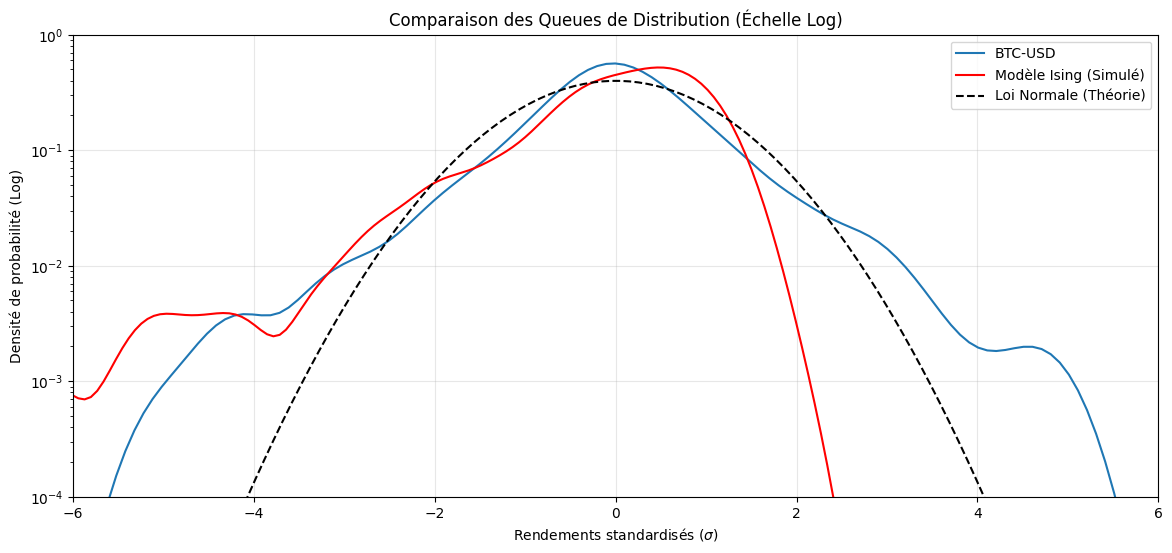

--- Résultats de l'Analyse ---
Volatilité (Ecart-type) : 0.004148639640211709
Asymétrie (Skewness) : -2.3857936090647383
Excès de Kurtosis : 11.638753454131894
Jarque-Bera p-value : 0.0
Est une Loi Normale ? : False
Susceptibility : 51.724498184500376


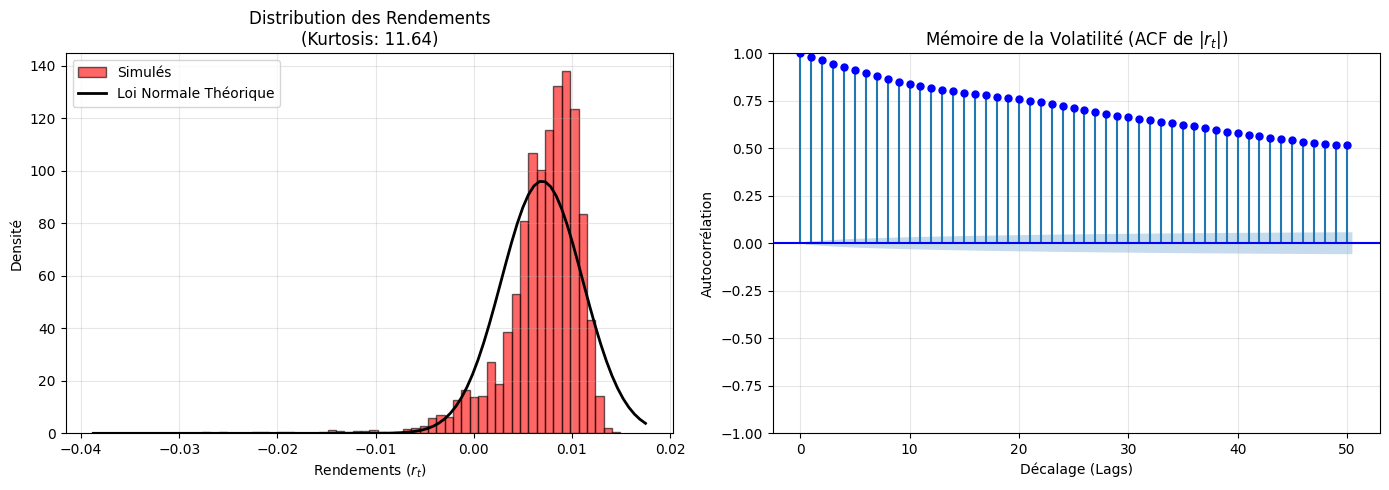

In [9]:
print(best_filename)

analyzer = MarketMetrics(best_filename)

compare_to_reality(analyzer.df['r_history'], real_returns) # Remplace chi_vals par tes r_t simulés

financial_stats = analyzer.analyze_returns()

print("--- Résultats de l'Analyse ---")
for metric, valeur in financial_stats.items():
    print(f"{metric} : {valeur}")
    
susceptibility = analyzer.calculate_susceptibility(N, T)
print(f"Susceptibility : {susceptibility}")

# 3. Afficher les graphiques de validation (Histogramme + ACF)
analyzer.plot_stylized_facts()